In [1]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [7]:
data = {
    "Gr_Studies": ["No", "Yes", "No", "No", "No", "Yes", "No", "Yes", "No", "Yes", "No", "No"],
    "Family_Wealth": ["Poor", "Rich", "Rich", "Poor", "Rich", "Middle", "Rich", "Middle", "Poor", "Poor", "Poor", "Poor"],
    "Risk": ["RA", "RS", "RA", "RS", "RA", "RS", "RA", "RS", "RS", "RS", "RS", "RS"],
    "Duration": ["M", "Q", "F", "M", "M", "F", "M", "F", "F", "M", "M", "Q"]
}

import pandas as pd
df = pd.DataFrame(data)
df.columns = ['Gr_Studies', 	'Family_Wealth',	'Risk',	'Duration']

df = df.rename(columns={
    "Gr_Studies":"grad_studies",
    "Family_Wealth":"family_wealth",
    "Duration" : "duration",
    "Risk" : "risk"
})

df

,grad_studies,family_wealth,risk,duration
0,No,Poor,RA,M
1,Yes,Rich,RS,Q
2,No,Rich,RA,F
3,No,Poor,RS,M
4,No,Rich,RA,M
5,Yes,Middle,RS,F
6,No,Rich,RA,M
7,Yes,Middle,RS,F
8,No,Poor,RS,F
9,Yes,Poor,RS,M


In [8]:
poor = df[df["family_wealth"] == "Poor"]
middle = df[df["family_wealth"] == "Middle"]
rich = df[df["family_wealth"] == "Rich"]

In [3]:
#compare information gain
def entropy(y):
    counts = y.value_counts(normalize=True)
    return -np.sum(counts*np.log2(counts))

def weighted_entropy(groups, target_col):
    total = sum(len(g) for g in groups)
    return sum((len(g)/total)*entropy(g[target_col]) for g in groups)

def information_gain(df, groups, target_col):
    return entropy(df[target_col]) - weighted_entropy(groups, target_col)

In [9]:
h3 = weighted_entropy([poor, middle, rich], "duration")
ig3 = information_gain(df, [poor, middle, rich], "duration")

In [10]:
split1_left = df[df["family_wealth"] == "Poor"]
split1_right = df[df["family_wealth"] != "Poor"]

split2_left = df[df["family_wealth"] == "Rich"]
split2_right = df[df["family_wealth"] != "Rich"]

split3_left = df[df["family_wealth"] == "Middle"]
split3_right = df[df["family_wealth"] != "Middle"]

In [11]:
print("Weighted entropy for 3-way split:", h3)
print("Information gain for 3-way split:", ig3)
print()
binary_entropy_values=[]
binary_ig_values = []
idx = 0
for name, groups in {
    "Poor | ~Poor": [split1_left, split1_right],
    "Rich | ~Rich": [split2_left, split2_right],
    "Middle | ~Middle": [split3_left, split3_right],
}.items():
    h = weighted_entropy(groups, "duration")
    ig = information_gain(df, groups, "duration")
    binary_ig_values.append(ig)
    binary_entropy_values.append(h)
    print(name)
    print("  weighted entropy:", h)
    print("  information gain:", ig)
    print()


Weighted entropy for 3-way split: 1.1258145836939115
Information gain for 3-way split: 0.33333333333333326

Poor | ~Poor
  weighted entropy: 1.3553885422075338
  information gain: 0.10375937481971098

Rich | ~Rich
  weighted entropy: 1.4370927081530442
  information gain: 0.022055208874200538

Middle | ~Middle
  weighted entropy: 1.142458828712224
  information gain: 0.31668908831502085



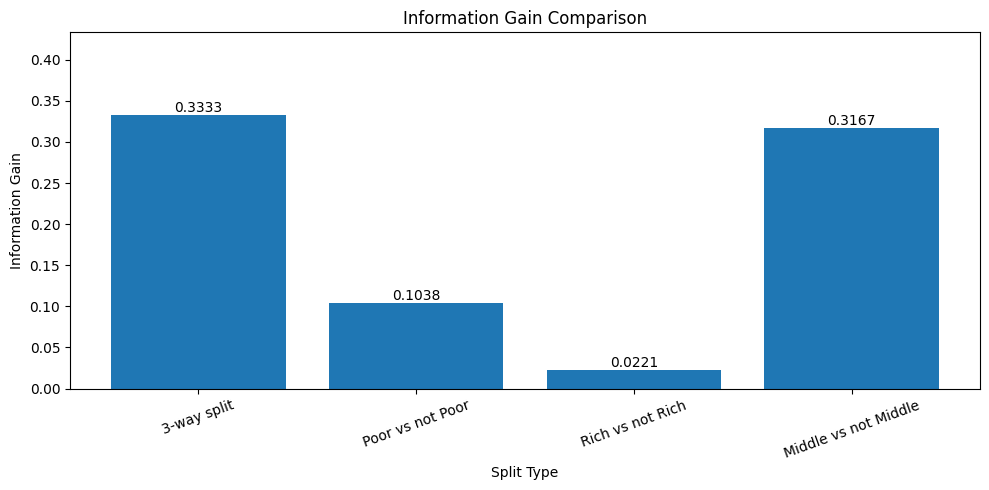

In [12]:
# --------------------------------------------------
# Plot 1: Compare information gain
# --------------------------------------------------

plot_names = [
    "3-way split",
    "Poor vs not Poor",
    "Rich vs not Rich",
    "Middle vs not Middle",
]

plot_ig_values = [
    ig3,
    binary_ig_values[0],
    binary_ig_values[1],
    binary_ig_values[2]
]

plt.figure(figsize=(10, 5))
bars = plt.bar(plot_names, plot_ig_values)

plt.title("Information Gain Comparison")
plt.xlabel("Split Type")
plt.ylabel("Information Gain")
plt.ylim(0, max(plot_ig_values) + 0.1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        round(height, 4),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


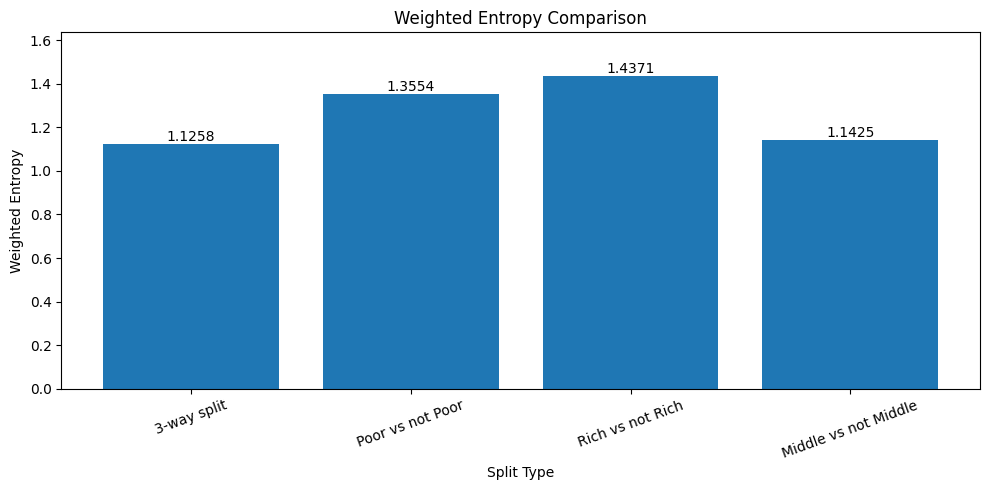

In [13]:


# --------------------------------------------------
# Plot 2: Compare weighted entropy
# Lower weighted entropy is better
# --------------------------------------------------

plot_entropy_values = [
    h3,
    binary_entropy_values[0],
    binary_entropy_values[1],
    binary_entropy_values[2]
]

plt.figure(figsize=(10, 5))
bars = plt.bar(plot_names, plot_entropy_values)

plt.title("Weighted Entropy Comparison")
plt.xlabel("Split Type")
plt.ylabel("Weighted Entropy")
plt.ylim(0, max(plot_entropy_values) + 0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        round(height, 4),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()